In [4]:
import json
import os

statsbomb_path = "../data/raw/statsbomb/data"

with open(os.path.join(statsbomb_path, "competitions.json")) as f:
    competitions = json.load(f)

# filter to only competition IDs that exist in the matches folder
available_ids = set(os.listdir(os.path.join(statsbomb_path, "matches")))

print(f"{'ID':<8} {'Competition':<35} {'Season'}")
print("-" * 70)
for c in competitions:
    if str(c['competition_id']) in available_ids:
        print(f"{c['competition_id']:<8} {c['competition_name']:<35} {c['season_name']}")

ID       Competition                         Season
----------------------------------------------------------------------
9        1. Bundesliga                       2023/2024
9        1. Bundesliga                       2015/2016
1267     African Cup of Nations              2023
16       Champions League                    2018/2019
16       Champions League                    2017/2018
16       Champions League                    2016/2017
16       Champions League                    2015/2016
16       Champions League                    2014/2015
16       Champions League                    2013/2014
16       Champions League                    2012/2013
16       Champions League                    2011/2012
16       Champions League                    2010/2011
16       Champions League                    2009/2010
16       Champions League                    2008/2009
16       Champions League                    2006/2007
16       Champions League                    2004/2005
16

Use results.csv goals for Elo computation across all 45k matches, but then train XGBoost on the StatsBomb subset using real xG as target. Elo features come from the full history, xG labels come from StatsBomb only.


ELO from results.csv xG from statsbomb

load results.csv
filter: date < 2022-11-20
replay all matches chronologically
maintain running elo dict {team: elo_rating}
at each match, snapshot {home_elo, away_elo} BEFORE updating
update elo after result
save full elo history to data/processed/elo_history.csv

load matches from competition 43 (WC) seasons: 1958,1962,1970,1974,1986,1990,2018
load matches from competition 55 (Euro) seasons: 2020
load matches from competition 223 (Copa) seasons: 2024
load matches from competition 1267 (AFCON) seasons: 2023
for each match, sum shot xG per team → home_xG, away_xG
output: {date, home_team, away_team, home_xG, away_xG}
save to data/processed/statsbomb_match_xg.csv

join statsbomb_match_xg with elo_history on date + teams
features: home_elo, away_elo, elo_diff, tournament_type
target: home_xG, away_xG
save to data/processed/training_set.csv

train two regressors: home_xG_model, away_xG_model
features: home_elo, away_elo, elo_diff, tournament_type
validate on WC 2022 matches
report MAE on predicted vs actual xG
save models to models/home_xg_model.json, away_xg_model.json

In [5]:
import pandas as pd
import numpy as np
import json
import os
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Paths
DATA_RAW       = "../data/raw"
DATA_PROCESSED = "../data/processed"
STATSBOMB_PATH = "../data/raw/statsbomb/data"

# Temporal cutoffs
TRAIN_CUTOFF = "2022-11-19"
VAL_START    = "2022-11-20"
VAL_END      = "2022-12-18"

# StatsBomb competitions to use
STATSBOMB_COMPS = {
    43:  ["2018", "1990", "1986", "1974", "1970", "1962", "1958"],  # FIFA World Cup (exclude 2022 - validation only)
    55:  ["2020"],                                                    # UEFA Euro
    223: ["2024"],                                                    # Copa America
    1267:["2023"],                                                    # AFCON
}

# WC 2022 StatsBomb - validation only
WC2022_COMP_ID = 43
WC2022_SEASON  = "2022"

In [24]:
results = pd.read_csv("../data/raw/kaggle/results.csv")
results['date'] = pd.to_datetime(results['date'])
train = results[results['date']<=TRAIN_CUTOFF]
val = results[
    (results['date'] >= VAL_START) & 
    (results['date'] <= VAL_END) & 
    (results['tournament'] == 'FIFA World Cup')
]


print(val.shape)
print(train.shape)

(64, 9)
(45700, 9)


In [28]:
K = 32
DEFAULT_ELO = 1500

elo = {}  # team name : current elo
elo_records = []  # elo snapshot before each match

def get_elo(team):
    return elo.get(team, DEFAULT_ELO)

for idx, row in train.iterrows():
    home = row['home_team']
    away = row['away_team']
    home_elo = get_elo(home)
    away_elo = get_elo(away)
    elo_records.append(
        {
            'date': row['date'],
            'home_team': home,
            'away_team': away,
            'home_elo': home_elo,
            'away_elo': away_elo
        })
    # expected outcome
    expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
    # actual outcome
    if row['home_score'] > row['away_score']:
        actual_home = 1      # home win
    elif row['home_score'] == row['away_score']:
        actual_home = 0.5    # draw
    else:
        actual_home = 0      # away win
    
    # update elo
    elo[home] = home_elo + K * (actual_home - expected_home)
    elo[away] = away_elo + K * ((1 - actual_home) - (1 - expected_home))


elo_history = pd.DataFrame(elo_records)
print(elo_history.shape)
elo_history.tail(10)





(45700, 5)


,date,home_team,away_team,home_elo,away_elo
45690,2022-11-19,Ivory Coast,Burkina Faso,1713.609888,1631.151970
45691,2022-11-19,Kosovo,Faroe Islands,1570.140784,1381.787512
45692,2022-11-19,Kuwait,Lebanon,1438.161781,1472.159578
45693,2022-11-19,Peru,Bolivia,1815.124874,1592.095524
45694,2022-11-19,Rwanda,Sudan,1427.036737,1397.057149
45695,2022-11-19,Sweden,Algeria,1767.206545,1802.959551
45696,2022-11-19,Turkey,Czech Republic,1726.997984,1761.597646
45697,2022-11-19,United Arab Emirates,Kazakhstan,1595.786355,1476.349114
45698,2022-11-19,Estonia,Lithuania,1501.082294,1360.982317
45699,2022-11-19,Latvia,Iceland,1425.996622,1596.210037


In [29]:
top_teams = ['Brazil', 'France', 'Germany', 'Argentina', 'Spain', 'England']
for team in top_teams:
    print(f"{team}: {get_elo(team):.1f}")

Brazil: 2081.7
France: 1961.2
Germany: 1926.4
Argentina: 2041.0
Spain: 1984.4
England: 1935.7


In [30]:
elo_history.to_csv("../data/processed/elo_history.csv", index=False)
print("saved")

saved


Saved Elo history upto wc 2022

In [31]:
# look at one matches file to understand structure
with open(f"{STATSBOMB_PATH}/matches/43/3.json") as f:
    matches = json.load(f)

# print first match to see structure
print(json.dumps(matches[0], indent=2))

{
  "match_id": 8650,
  "match_date": "2018-07-06",
  "kick_off": "18:00:00.000",
  "competition": {
    "competition_id": 43,
    "country_name": "International",
    "competition_name": "FIFA World Cup"
  },
  "season": {
    "season_id": 3,
    "season_name": "2018"
  },
  "home_team": {
    "home_team_id": 781,
    "home_team_name": "Brazil",
    "home_team_gender": "male",
    "home_team_group": null,
    "country": {
      "id": 31,
      "name": "Brazil"
    },
    "managers": [
      {
        "id": 547,
        "name": "Adenor Leonardo Bacchi",
        "nickname": "Tite",
        "dob": "1961-05-25",
        "country": {
          "id": 31,
          "name": "Brazil"
        }
      }
    ]
  },
  "away_team": {
    "away_team_id": 782,
    "away_team_name": "Belgium",
    "away_team_gender": "male",
    "away_team_group": null,
    "country": {
      "id": 22,
      "name": "Belgium"
    },
    "managers": [
      {
        "id": 263,
        "name": "Roberto Mart\u00c3\u00ad

In [32]:
with open(f"{STATSBOMB_PATH}/competitions.json") as f:
    comps = json.load(f)

for c in comps:
    if c['competition_id'] == 43:
        print(f"Season: {c['season_name']:10s} | season_id: {c['season_id']}")

Season: 2022       | season_id: 106
Season: 2018       | season_id: 3
Season: 1990       | season_id: 55
Season: 1986       | season_id: 54
Season: 1974       | season_id: 51
Season: 1970       | season_id: 272
Season: 1962       | season_id: 270
Season: 1958       | season_id: 269


In [33]:
for c in comps:
    if c['competition_id'] in [55, 223, 1267]:
        print(f"Comp: {c['competition_name']:20s} | Season: {c['season_name']:10s} | season_id: {c['season_id']}")
        

Comp: African Cup of Nations | Season: 2023       | season_id: 107
Comp: Copa America         | Season: 2024       | season_id: 282
Comp: UEFA Euro            | Season: 2024       | season_id: 282
Comp: UEFA Euro            | Season: 2020       | season_id: 43


In [39]:
STATSBOMB_COMPS = {
    43  : [3, 55, 54, 51, 272, 270, 269],  # FIFA World Cup (2018, 1990, 1986, 1974, 1970, 1962, 1958)
    55  : [282, 43],                         # UEFA Euro (2024, 2020)
    223 : [282],                             # Copa America (2024)
    1267: [107],                             # AFCON (2023)
}

WC2022_SEASON_ID = 106  # validation only

def load_matches(comp_id, season_id):
    path = f"{STATSBOMB_PATH}/matches/{comp_id}/{season_id}.json"
    with open(path, encoding='utf-8') as f:
        matches = json.load(f)
    return matches

def extract_match_xg(match):
    match_id = match['match_id']
    home_team = match['home_team']['home_team_name']
    away_team = match['away_team']['away_team_name']
    
    with open(f"{STATSBOMB_PATH}/events/{match_id}.json", encoding='utf-8') as f:
        events = json.load(f)
    
    home_xg = sum(
        e['shot']['statsbomb_xg']
        for e in events
        if e['type']['name'] == 'Shot' and e['team']['name'] == home_team
    )
    away_xg = sum(
        e['shot']['statsbomb_xg']
        for e in events
        if e['type']['name'] == 'Shot' and e['team']['name'] == away_team
    )
    
    return {
        'date'     : match['match_date'],
        'home_team': home_team,
        'away_team': away_team,
        'home_xg'  : home_xg,
        'away_xg'  : away_xg
    }

# test on one match
print(extract_match_xg(matches[0]))
all_xg_records = []

for comp_id, season_ids in STATSBOMB_COMPS.items():
    for season_id in season_ids:
        matches = load_matches(comp_id, season_id)
        for match in matches:
            record = extract_match_xg(match)
            all_xg_records.append(record)

statsbomb_xg = pd.DataFrame(all_xg_records)
statsbomb_xg['date'] = pd.to_datetime(statsbomb_xg['date'])
print(statsbomb_xg.shape)
statsbomb_xg.head()


{'date': '2018-07-06', 'home_team': 'Brazil', 'away_team': 'Belgium', 'home_xg': 2.6091956662, 'away_xg': 0.405256133}
(269, 5)


,date,home_team,away_team,home_xg,away_xg
0,2018-07-06,Brazil,Belgium,2.609196,0.405256
1,2018-07-02,Belgium,Japan,2.917832,0.693769
2,2018-06-24,England,Panama,3.168321,1.080039
3,2018-06-19,Poland,Senegal,1.042323,1.427751
4,2018-06-22,Serbia,Switzerland,1.153485,1.557309


In [40]:
statsbomb_xg.to_csv("../data/processed/statsbomb_match_xg.csv", index=False)
print("saved")

saved


In [48]:
training_set = pd.merge(
    statsbomb_xg,
    elo_history,
    on=['date', 'home_team', 'away_team'],
    how='inner'
)

print(training_set.shape)
training_set.head()

(117, 7)


,date,home_team,away_team,home_xg,away_xg,home_elo,away_elo
0,2018-07-06,Brazil,Belgium,2.609196,0.405256,2070.264487,1956.536993
1,2018-07-02,Belgium,Japan,2.917832,0.693769,1949.173807,1739.366269
2,2018-06-24,England,Panama,3.168321,1.080039,1939.609048,1663.204408
3,2018-06-19,Poland,Senegal,1.042323,1.427751,1810.956504,1748.457533
4,2018-06-22,Serbia,Switzerland,1.153485,1.557309,1749.193920,1864.161697


In [42]:
# find unmatched rows
merged_check = pd.merge(
    statsbomb_xg,
    elo_history,
    on=['date', 'home_team', 'away_team'],
    how='left',
    indicator=True
)

unmatched = merged_check[merged_check['_merge'] == 'left_only']
print(unmatched[['date', 'home_team', 'away_team']].to_string())

          date           home_team           away_team
39  2018-06-25             Uruguay              Russia
45  2018-07-01               Spain              Russia
69  1974-07-07         Netherlands             Germany
73  1974-06-22           German DR             Germany
76  1970-06-09              Brazil             Romania
81  1958-06-29              Brazil              Sweden
83  2024-06-18            Portugal      Czech Republic
84  2024-06-15             Hungary         Switzerland
85  2024-06-16              Serbia             England
86  2024-06-25             England            Slovenia
87  2024-06-24             Croatia               Italy
88  2024-06-15               Spain             Croatia
89  2024-06-20            Slovenia              Serbia
90  2024-06-25              France              Poland
91  2024-06-21              Poland             Austria
92  2024-06-22             Georgia      Czech Republic
93  2024-06-18              Turkey             Georgia
94  2024-0

In [43]:
# check a few specific mismatched names in results.csv
check_teams = ['Ivory Coast', "Côte d'Ivoire", 'Cape Verde', 'Cape Verde Islands', 
               'West Germany', 'Germany', 'Netherlands', 'Russia']

for team in check_teams:
    count = len(results[results['home_team'] == team])
    print(f"{team}: {count} matches as home team")

Ivory Coast: 323 matches as home team
Côte d'Ivoire: 0 matches as home team
Cape Verde: 123 matches as home team
Cape Verde Islands: 0 matches as home team
West Germany: 0 matches as home team
Germany: 556 matches as home team
Netherlands: 478 matches as home team
Russia: 330 matches as home team


In [44]:
check_teams = ['United States', 'North Macedonia', 'DR Congo', 'Congo DR']
for team in check_teams:
    count = len(results[results['home_team'] == team])
    print(f"{team}: {count} matches as home team")

United States: 502 matches as home team
North Macedonia: 151 matches as home team
DR Congo: 223 matches as home team
Congo DR: 0 matches as home team


In [54]:
TEAM_NAME_MAP = {
    "Côte d'Ivoire"     : "Ivory Coast",
    "Cape Verde Islands": "Cape Verde",
    "Congo DR"          : "DR Congo",
}
# create a match key that's order-independent
statsbomb_xg['match_key'] = statsbomb_xg.apply(
    lambda r: '_'.join(sorted([r['home_team'], r['away_team']])), axis=1
)
elo_history['match_key'] = elo_history.apply(
    lambda r: '_'.join(sorted([r['home_team'], r['away_team']])), axis=1
)

training_set = pd.merge(
    statsbomb_xg,
    elo_history[['date', 'match_key', 'home_elo', 'away_elo']],
    on=['date', 'match_key'],
    how='inner'
)

print(training_set.shape)

(133, 8)


In [55]:
# see what's still unmatched
merged_check = pd.merge(
    statsbomb_xg,
    elo_history[['date', 'match_key', 'home_elo', 'away_elo']],
    on=['date', 'match_key'],
    how='left',
    indicator=True
)

unmatched = merged_check[merged_check['_merge'] == 'left_only']
print(unmatched[['date', 'home_team', 'away_team']].head(20).to_string())
print(f"\nTotal unmatched: {len(unmatched)}")

          date home_team       away_team
76  1970-06-09    Brazil         Romania
83  2024-06-18  Portugal  Czech Republic
84  2024-06-15   Hungary     Switzerland
85  2024-06-16    Serbia         England
86  2024-06-25   England        Slovenia
87  2024-06-24   Croatia           Italy
88  2024-06-15     Spain         Croatia
89  2024-06-20  Slovenia          Serbia
90  2024-06-25    France          Poland
91  2024-06-21    Poland         Austria
92  2024-06-22   Georgia  Czech Republic
93  2024-06-18    Turkey         Georgia
94  2024-06-17   Romania         Ukraine
95  2024-06-21  Slovakia         Ukraine
96  2024-06-16    Poland     Netherlands
97  2024-06-26   Georgia        Portugal
98  2024-07-01    France         Belgium
99  2024-07-06   England     Switzerland
100 2024-06-22    Turkey        Portugal
101 2024-06-16  Slovenia         Denmark

Total unmatched: 136


In [56]:
statsbomb_xg_train = statsbomb_xg[statsbomb_xg['date'] < VAL_START]
print(statsbomb_xg_train.shape)

(134, 6)


In [57]:
training_set = pd.merge(
    statsbomb_xg_train,
    elo_history[['date', 'match_key', 'home_elo', 'away_elo']],
    on=['date', 'match_key'],
    how='inner'
)

print(training_set.shape)

(133, 8)


In [58]:
print(training_set.columns.tolist())
training_set.head()

['date', 'home_team', 'away_team', 'home_xg', 'away_xg', 'match_key', 'home_elo', 'away_elo']


,date,home_team,away_team,home_xg,away_xg,match_key,home_elo,away_elo
0,2018-07-06,Brazil,Belgium,2.609196,0.405256,Belgium_Brazil,2070.264487,1956.536993
1,2018-07-02,Belgium,Japan,2.917832,0.693769,Belgium_Japan,1949.173807,1739.366269
2,2018-06-24,England,Panama,3.168321,1.080039,England_Panama,1939.609048,1663.204408
3,2018-06-19,Poland,Senegal,1.042323,1.427751,Poland_Senegal,1810.956504,1748.457533
4,2018-06-22,Serbia,Switzerland,1.153485,1.557309,Serbia_Switzerland,1749.193920,1864.161697


In [59]:
# elo difference
training_set['elo_diff'] = training_set['home_elo'] - training_set['away_elo']

# tournament type - all StatsBomb training data is World Cup so it's all 1.0
training_set['is_worldcup'] = 1

# save it
training_set.to_csv("../data/processed/training_set.csv", index=False)

print(training_set.shape)
training_set[['home_elo', 'away_elo', 'elo_diff', 'home_xg', 'away_xg']].describe()

(133, 10)


,home_elo,away_elo,elo_diff,home_xg,away_xg
count,133.000000,133.000000,133.000000,133.000000,133.000000
mean,1849.259094,1817.453484,31.805610,1.752447,1.449467
std,105.239227,111.994368,147.593477,1.298917,1.215867
min,1626.690696,1616.352973,-351.663122,0.093043,0.132008
25%,1756.276742,1731.805256,-78.166451,0.910466,0.697556
50%,1863.364770,1802.474224,53.489889,1.429754,1.121568
75%,1938.755163,1909.504301,150.905501,2.097695,1.660947
max,2070.264487,2058.692198,337.156026,6.563390,6.928069


In [62]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

features = ['home_elo', 'away_elo', 'elo_diff', 'is_worldcup']

X = training_set[features]
y_home = training_set['home_xg']
y_away = training_set['away_xg']

home_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
away_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)

home_model.fit(X, y_home)
away_model.fit(X, y_away)

home_preds = home_model.predict(X)
away_preds = away_model.predict(X)

print(f"Home xG MAE: {mean_absolute_error(y_home, home_preds):.4f}")
print(f"Away xG MAE: {mean_absolute_error(y_away, away_preds):.4f}")

Home xG MAE: 0.4759
Away xG MAE: 0.3484


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

home_preds = home_model.predict(X)
away_preds = away_model.predict(X)

for label, y_true, y_pred in [('Home xG', y_home, home_preds), ('Away xG', y_away, away_preds)]:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label}:")
    print(f"  MAE  : {mae:.4f}")   # average error in xG units
    print(f"  RMSE : {rmse:.4f}")  # penalises large errors more
    print(f"  R²   : {r2:.4f}")    # 1.0 = perfect, 0.0 = no better than mean
    print()

Home xG:
  MAE  : 0.4759
  RMSE : 0.6408
  R²   : 0.7547

Away xG:
  MAE  : 0.3484
  RMSE : 0.4843
  R²   : 0.8401



In [64]:
from sklearn.model_selection import cross_val_score

home_cv = cross_val_score(
    XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
    X, y_home, cv=5, scoring='neg_mean_absolute_error'
)
away_cv = cross_val_score(
    XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
    X, y_away, cv=5, scoring='neg_mean_absolute_error'
)

print(f"Home xG CV MAE: {-home_cv.mean():.4f} (+/- {home_cv.std():.4f})")
print(f"Away xG CV MAE: {-away_cv.mean():.4f} (+/- {away_cv.std():.4f})")

Home xG CV MAE: 1.0708 (+/- 0.1495)
Away xG CV MAE: 0.9519 (+/- 0.1111)


In [65]:
home_model = XGBRegressor(
    n_estimators=50,      # fewer trees
    learning_rate=0.05,
    max_depth=2,          # shallower trees
    subsample=0.8,        # random row sampling
    colsample_bytree=0.8, # random feature sampling
    reg_alpha=0.1,        # L1 regularisation
    reg_lambda=1.5,       # L2 regularisation
    random_state=42
)
away_model = XGBRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42
)

home_model.fit(X, y_home)
away_model.fit(X, y_away)

# check CV MAE again
home_cv = cross_val_score(
    XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=2, subsample=0.8, 
                 colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.5, random_state=42),
    X, y_home, cv=5, scoring='neg_mean_absolute_error'
)
away_cv = cross_val_score(
    XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=2, subsample=0.8,
                 colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.5, random_state=42),
    X, y_away, cv=5, scoring='neg_mean_absolute_error'
)

print(f"Home xG CV MAE: {-home_cv.mean():.4f} (+/- {home_cv.std():.4f})")
print(f"Away xG CV MAE: {-away_cv.mean():.4f} (+/- {away_cv.std():.4f})")

Home xG CV MAE: 0.9879 (+/- 0.1132)
Away xG CV MAE: 0.8644 (+/- 0.0608)


Stats bomb subset only has 133 matches - its too small for xgboost the model is overfitting

In [67]:
# add match key to train
train['match_key'] = train.apply(
    lambda r: '_'.join(sorted([r['home_team'], r['away_team']])), axis=1
)

# join with elo_history
full_training_set = pd.merge(
    train,
    elo_history[['date', 'match_key', 'home_elo', 'away_elo']],
    on=['date', 'match_key'],
    how='inner'
)

full_training_set['elo_diff'] = full_training_set['home_elo'] - full_training_set['away_elo']
full_training_set['is_worldcup'] = (full_training_set['tournament'] == 'FIFA World Cup').astype(int)

print(full_training_set.shape)
full_training_set.head(20)

(45732, 14)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_key,home_elo,away_elo,elo_diff,is_worldcup
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,England_Scotland,1500.000000,1500.000000,0.000000,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,England_Scotland,1500.000000,1500.000000,0.000000,0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,England_Scotland,1484.000000,1516.000000,-32.000000,0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,England_Scotland,1498.530498,1501.469502,-2.939003,0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,England_Scotland,1501.334159,1498.665841,2.668317,0
5,1876-03-25,Scotland,Wales,4.0,0.0,Friendly,Glasgow,Scotland,False,Scotland_Wales,1517.211281,1500.000000,17.211281,0
6,1877-03-03,England,Scotland,1.0,3.0,Friendly,London,England,False,England_Scotland,1482.788719,1532.419319,-49.630600,0
7,1877-03-05,Wales,Scotland,0.0,2.0,Friendly,Wrexham,Wales,False,Scotland_Wales,1484.791961,1546.149166,-61.357205,0
8,1878-03-02,Scotland,England,7.0,2.0,Friendly,Glasgow,Scotland,False,England_Scotland,1559.352575,1469.058873,90.293703,0
9,1878-03-23,Scotland,Wales,9.0,0.0,Friendly,Glasgow,Scotland,False,Scotland_Wales,1571.285550,1471.588552,99.696998,0


In [68]:
features = ['home_elo', 'away_elo', 'elo_diff', 'is_worldcup']

X = full_training_set[features]
y_home = full_training_set['home_score']
y_away = full_training_set['away_score']

home_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42
)
away_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42
)

home_model.fit(X, y_home)
away_model.fit(X, y_away)

home_cv = cross_val_score(
    home_model, X, y_home, cv=5, scoring='neg_mean_absolute_error'
)
away_cv = cross_val_score(
    away_model, X, y_away, cv=5, scoring='neg_mean_absolute_error'
)

print(f"Home goals CV MAE: {-home_cv.mean():.4f} (+/- {home_cv.std():.4f})")
print(f"Away goals CV MAE: {-away_cv.mean():.4f} (+/- {away_cv.std():.4f})")

Home goals CV MAE: 1.1685 (+/- 0.0999)
Away goals CV MAE: 0.9399 (+/- 0.0856)


In [70]:
test_matches = pd.DataFrame([
    {'home_elo': 2081, 'away_elo': 1500, 'elo_diff': 581, 'is_worldcup': 1},  # Brazil vs weak team WC
    {'home_elo': 1500, 'away_elo': 2081, 'elo_diff': -581, 'is_worldcup': 1}, # weak team vs Brazil WC
    {'home_elo': 2081, 'away_elo': 1961, 'elo_diff': 120, 'is_worldcup': 1},  # Brazil vs France WC
    {'home_elo': 1961, 'away_elo': 1961, 'elo_diff': 0,   'is_worldcup': 1},  # equal teams WC
    {'home_elo': 1961, 'away_elo': 1961, 'elo_diff': 0,   'is_worldcup': 0},  # equal teams friendly
])

home_preds = home_model.predict(test_matches[features])
away_preds = away_model.predict(test_matches[features])

test_matches['predicted_home_goals'] = home_preds
test_matches['predicted_away_goals'] = away_preds
print(test_matches.to_string())

   home_elo  away_elo  elo_diff  is_worldcup  predicted_home_goals  predicted_away_goals
0      2081      1500       581            1              5.112650              0.556242
1      1500      2081      -581            1              0.512650              3.380248
2      2081      1961       120            1              1.589571              1.529931
3      1961      1961         0            1              1.290664              1.114477
4      1961      1961         0            0              1.326590              1.065302


In [71]:
# add elo and match key to val
val['match_key'] = val.apply(
    lambda r: '_'.join(sorted([r['home_team'], r['away_team']])), axis=1
)

val_set = pd.merge(
    val,
    elo_history[['date', 'match_key', 'home_elo', 'away_elo']],
    on=['date', 'match_key'],
    how='inner'
)

val_set['elo_diff'] = val_set['home_elo'] - val_set['away_elo']
val_set['is_worldcup'] = 1

print(val_set.shape)

(0, 14)


In [72]:
print(elo_history[elo_history['date'] >= '2022-11-20'].head(10).to_string())

Empty DataFrame
Columns: [date, home_team, away_team, home_elo, away_elo, match_key]
Index: []


In [74]:
# get final elo for each team from the elo dict
def get_val_elo(row):
    home = row['home_team']
    away = row['away_team']
    return pd.Series({
        'home_elo': get_elo(home),
        'away_elo': get_elo(away)
    })

val_set = val.copy()
val_set[['home_elo', 'away_elo']] = val_set.apply(get_val_elo, axis=1)
val_set['elo_diff'] = val_set['home_elo'] - val_set['away_elo']
val_set['is_worldcup'] = 1

print(val_set.shape)
val_set.head(10)

(64, 14)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_key,home_elo,away_elo,elo_diff,is_worldcup
45717,2022-11-20,Qatar,Ecuador,0.0,2.0,FIFA World Cup,Al Khor,Qatar,False,Ecuador_Qatar,1738.877368,1799.722834,-60.845466,1
45718,2022-11-21,Senegal,Netherlands,0.0,2.0,FIFA World Cup,Doha,Qatar,True,Netherlands_Senegal,1735.492912,1976.018143,-240.525231,1
45719,2022-11-21,England,Iran,6.0,2.0,FIFA World Cup,Al Rayyan,Qatar,True,England_Iran,1935.726869,1839.324037,96.402833,1
45720,2022-11-21,United States,Wales,1.0,1.0,FIFA World Cup,Al Rayyan,Qatar,True,United States_Wales,1829.202667,1773.076047,56.126620,1
45721,2022-11-22,Argentina,Saudi Arabia,1.0,2.0,FIFA World Cup,Lusail,Qatar,True,Argentina_Saudi Arabia,2040.964632,1698.744604,342.220028,1
45722,2022-11-22,Mexico,Poland,0.0,0.0,FIFA World Cup,Doha,Qatar,True,Mexico_Poland,1793.304892,1814.322134,-21.017242,1
45723,2022-11-22,Denmark,Tunisia,0.0,0.0,FIFA World Cup,Al Rayyan,Qatar,True,Denmark_Tunisia,1908.558439,1743.686836,164.871603,1
45724,2022-11-22,France,Australia,4.0,1.0,FIFA World Cup,Al Wakrah,Qatar,True,Australia_France,1961.187867,1775.411246,185.776621,1
45725,2022-11-23,Germany,Japan,1.0,2.0,FIFA World Cup,Al Rayyan,Qatar,True,Germany_Japan,1926.429112,1829.242725,97.186387,1
45726,2022-11-23,Spain,Costa Rica,7.0,0.0,FIFA World Cup,Doha,Qatar,True,Costa Rica_Spain,1984.374052,1757.723344,226.650708,1


In [75]:
val_preds_home = home_model.predict(val_set[features])
val_preds_away = away_model.predict(val_set[features])

val_mae_home = mean_absolute_error(val_set['home_score'], val_preds_home)
val_mae_away = mean_absolute_error(val_set['away_score'], val_preds_away)

print(f"WC 2022 Validation:")
print(f"Home goals MAE: {val_mae_home:.4f}")
print(f"Away goals MAE: {val_mae_away:.4f}")

# also print a few predictions vs actuals
val_set['pred_home'] = val_preds_home
val_set['pred_away'] = val_preds_away
print(val_set[['home_team', 'away_team', 'home_score', 'away_score', 'pred_home', 'pred_away']].head(10).to_string())

WC 2022 Validation:
Home goals MAE: 1.0448
Away goals MAE: 0.8410
           home_team     away_team  home_score  away_score  pred_home  pred_away
45717          Qatar       Ecuador         0.0         2.0   1.179276   1.430788
45718        Senegal   Netherlands         0.0         2.0   0.895790   1.848771
45719        England          Iran         6.0         2.0   1.611622   0.961298
45720  United States         Wales         1.0         1.0   1.476669   1.038802
45721      Argentina  Saudi Arabia         1.0         2.0   2.401904   0.729150
45722         Mexico        Poland         0.0         0.0   1.335945   1.290209
45723        Denmark       Tunisia         0.0         0.0   1.885407   0.778464
45724         France     Australia         4.0         1.0   1.949597   0.804006
45725        Germany         Japan         1.0         2.0   1.601180   0.955861
45726          Spain    Costa Rica         7.0         0.0   2.118923   0.721862


In [76]:
import os
os.makedirs("../models", exist_ok=True)

home_model.save_model("../models/home_goals_model.json")
away_model.save_model("../models/away_goals_model.json")

full_training_set.to_csv("../data/processed/training_set.csv", index=False)
val_set.to_csv("../data/processed/val_set.csv", index=False)

print("saved")

saved


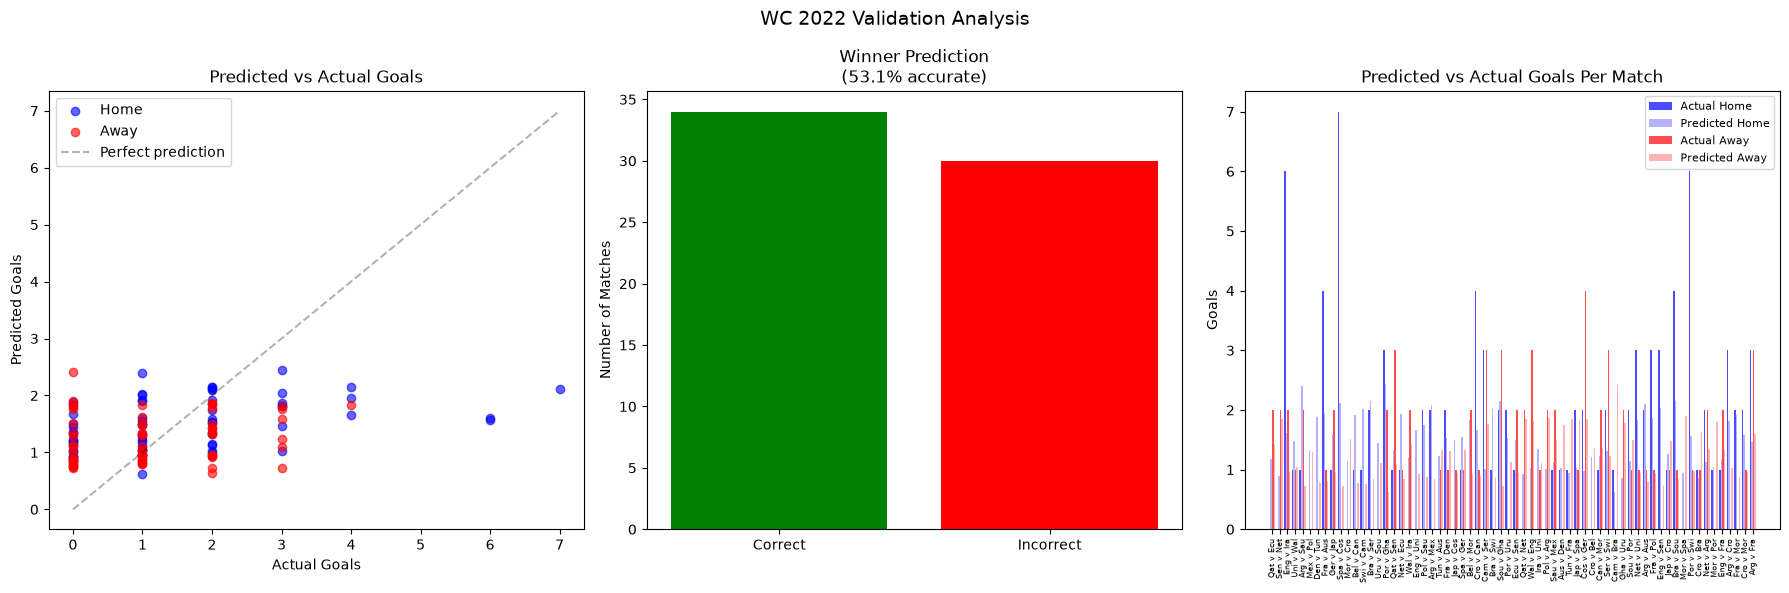

saved


In [77]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('WC 2022 Validation Analysis', fontsize=14)

# --- Plot 1: Predicted vs Actual Goals Scatter ---
ax1 = axes[0]
ax1.scatter(val_set['home_score'], val_set['pred_home'], 
            alpha=0.6, color='blue', label='Home')
ax1.scatter(val_set['away_score'], val_set['pred_away'], 
            alpha=0.6, color='red', label='Away')
ax1.plot([0, 7], [0, 7], 'k--', alpha=0.3, label='Perfect prediction')
ax1.set_xlabel('Actual Goals')
ax1.set_ylabel('Predicted Goals')
ax1.set_title('Predicted vs Actual Goals')
ax1.legend()

# --- Plot 2: Correct Winner Prediction Rate ---
ax2 = axes[1]
def get_result(home, away):
    if home > away: return 'home'
    elif away > home: return 'away'
    else: return 'draw'

val_set['actual_result']    = val_set.apply(lambda r: get_result(r['home_score'], r['away_score']), axis=1)
val_set['predicted_result'] = val_set.apply(lambda r: get_result(r['pred_home'], r['pred_away']), axis=1)
val_set['correct']          = val_set['actual_result'] == val_set['predicted_result']

correct_count   = val_set['correct'].sum()
incorrect_count = len(val_set) - correct_count
ax2.bar(['Correct', 'Incorrect'], [correct_count, incorrect_count], color=['green', 'red'])
ax2.set_title(f'Winner Prediction\n({correct_count/len(val_set)*100:.1f}% accurate)')
ax2.set_ylabel('Number of Matches')

# --- Plot 3: Predicted vs Actual Goals Per Match ---
ax3 = axes[2]
match_labels = [f"{r['home_team'][:3]} v {r['away_team'][:3]}" 
                for _, r in val_set.iterrows()]
x = np.arange(len(match_labels))
width = 0.2

ax3.bar(x - width*1.5, val_set['home_score'],  width, label='Actual Home',    color='blue',    alpha=0.7)
ax3.bar(x - width*0.5, val_set['pred_home'],   width, label='Predicted Home', color='blue',    alpha=0.3)
ax3.bar(x + width*0.5, val_set['away_score'],  width, label='Actual Away',    color='red',     alpha=0.7)
ax3.bar(x + width*1.5, val_set['pred_away'],   width, label='Predicted Away', color='red',     alpha=0.3)
ax3.set_xticks(x)
ax3.set_xticklabels(match_labels, rotation=90, fontsize=6)
ax3.set_title('Predicted vs Actual Goals Per Match')
ax3.set_ylabel('Goals')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/wc2022_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved")

In [78]:
print(full_training_set['tournament'].value_counts().head(10))

tournament
Friendly                                17444
FIFA World Cup qualification             7870
UEFA Euro qualification                  2585
African Cup of Nations qualification     2102
FIFA World Cup                            900
Copa América                              837
AFC Asian Cup qualification               764
African Cup of Nations                    741
CECAFA Cup                                620
CFU Caribbean Cup qualification           608
Name: count, dtype: int64


In [79]:
import numpy as np

# drop friendlies
competitive = full_training_set[full_training_set['tournament'] != 'Friendly'].copy()
print(f"Rows after dropping friendlies: {len(competitive)}")

# recency weight — exponential decay by year
# recent matches weighted higher
competitive['year'] = competitive['date'].dt.year
max_year = competitive['year'].max()
competitive['recency_weight'] = np.exp(0.05 * (competitive['year'] - max_year))

# WC matches get an extra boost on top
competitive['sample_weight'] = competitive['recency_weight']
competitive.loc[competitive['tournament'] == 'FIFA World Cup', 'sample_weight'] *= 2

print(competitive['sample_weight'].describe())
print(f"\nTournament breakdown:")
print(competitive['tournament'].value_counts().head(10))

Rows after dropping friendlies: 28288
count    28288.000000
mean         0.387329
std          0.291478
min          0.001008
25%          0.135335
50%          0.332871
75%          0.576950
max          1.637462
Name: sample_weight, dtype: float64

Tournament breakdown:
tournament
FIFA World Cup qualification            7870
UEFA Euro qualification                 2585
African Cup of Nations qualification    2102
FIFA World Cup                           900
Copa América                             837
AFC Asian Cup qualification              764
African Cup of Nations                   741
CECAFA Cup                               620
CFU Caribbean Cup qualification          608
Merdeka Tournament                       595
Name: count, dtype: int64


In [80]:
features = ['home_elo', 'away_elo', 'elo_diff', 'is_worldcup']

X = competitive[features]
y_home = competitive['home_score']
y_away = competitive['away_score']
weights = competitive['sample_weight']

home_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42
)
away_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42
)

home_model.fit(X, y_home, sample_weight=weights)
away_model.fit(X, y_away, sample_weight=weights)

# validate on WC 2022
val_preds_home = home_model.predict(val_set[features])
val_preds_away = away_model.predict(val_set[features])

val_set['pred_home'] = val_preds_home
val_set['pred_away'] = val_preds_away

val_set['actual_result']    = val_set.apply(lambda r: get_result(r['home_score'], r['away_score']), axis=1)
val_set['predicted_result'] = val_set.apply(lambda r: get_result(r['pred_home'], r['pred_away']), axis=1)
val_set['correct']          = val_set['actual_result'] == val_set['predicted_result']

print(f"Winner accuracy: {val_set['correct'].mean()*100:.1f}%")
print(f"Home MAE: {mean_absolute_error(val_set['home_score'], val_preds_home):.4f}")
print(f"Away MAE: {mean_absolute_error(val_set['away_score'], val_preds_away):.4f}")

Winner accuracy: 53.1%
Home MAE: 1.0406
Away MAE: 0.8374


In [81]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

X_sb = training_set[features]
y_home_sb = training_set['home_xg']
y_away_sb = training_set['away_xg']

models = {
    'Ridge'          : Ridge(),
    'Lasso'          : Lasso(),
    'Random Forest'  : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boost' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'        : XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
}

print(f"{'Model':<20} {'Home CV MAE':<15} {'Away CV MAE'}")
print("-" * 50)
for name, model in models.items():
    home_cv = cross_val_score(model, X_sb, y_home_sb, cv=5, scoring='neg_mean_absolute_error')
    away_cv = cross_val_score(model, X_sb, y_away_sb, cv=5, scoring='neg_mean_absolute_error')
    print(f"{name:<20} {-home_cv.mean():<15.4f} {-away_cv.mean():.4f}")

Model                Home CV MAE     Away CV MAE
--------------------------------------------------
Ridge                0.9336          0.8154
Lasso                0.9330          0.8149
Random Forest        1.0526          0.9477
Gradient Boost       1.1688          0.9864
XGBoost              1.0708          0.9519


In [82]:
from sklearn.linear_model import Ridge

ridge_home = Ridge()
ridge_away = Ridge()

ridge_home.fit(X_sb, y_home_sb)
ridge_away.fit(X_sb, y_away_sb)

val_ridge_home = ridge_home.predict(val_set[features])
val_ridge_away = ridge_away.predict(val_set[features])

val_set['pred_home'] = val_ridge_home
val_set['pred_away'] = val_ridge_away

val_set['predicted_result'] = val_set.apply(lambda r: get_result(r['pred_home'], r['pred_away']), axis=1)
val_set['correct'] = val_set['actual_result'] == val_set['predicted_result']

print(f"Ridge (133 rows xG) Winner accuracy: {val_set['correct'].mean()*100:.1f}%")
print(f"Home MAE: {mean_absolute_error(val_set['home_score'], val_ridge_home):.4f}")
print(f"Away MAE: {mean_absolute_error(val_set['away_score'], val_ridge_away):.4f}")

Ridge (133 rows xG) Winner accuracy: 48.4%
Home MAE: 1.1267
Away MAE: 0.9456


Ok so using a different model on the statsbomb dataset does nto fix anything, we just dont have enough data. XGboost on the elo ratings gave a better prediction

In [83]:
# save final model
competitive.to_csv("../data/processed/training_set.csv", index=False)
val_set.to_csv("../data/processed/val_set.csv", index=False)

home_model.save_model("../models/home_goals_model.json")
away_model.save_model("../models/away_goals_model.json")

print("Phase 4 complete")
print(f"Final model: XGBoost trained on {len(competitive)} competitive matches")
print(f"Validation winner accuracy: 53.1%")
print(f"Validation Home MAE: 1.04")
print(f"Validation Away MAE: 0.84")

Phase 4 complete
Final model: XGBoost trained on 28288 competitive matches
Validation winner accuracy: 53.1%
Validation Home MAE: 1.04
Validation Away MAE: 0.84
